Reducing dimensions of the distance matrix with PCA to prepare for clustering.

In [1]:
!pip install scikit-learn #Installing sklearn
!pip install matplotlib #Installing matplotlib


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
df_distance_matrix = pd.read_csv('../blasting/antibodies_distance_matrix.csv', index_col=0) #Reading the distance matrix into a Dataframe

pca = PCA(n_components=3) #Saves amount of components to variable "pca"
principal_components_MSA = pca.fit_transform(df_distance_matrix)  #Saves matrix transformed through PCA 

print(pca.explained_variance_ratio_) #Prints the explained variance of each Principal Component

pd.DataFrame(principal_components_MSA, index=df_distance_matrix.index, columns=['PC1', 'PC2', 'PC3']).to_csv('../blasting/antibodies_principal_components.csv')



[0.93306234 0.04212088 0.00831613]


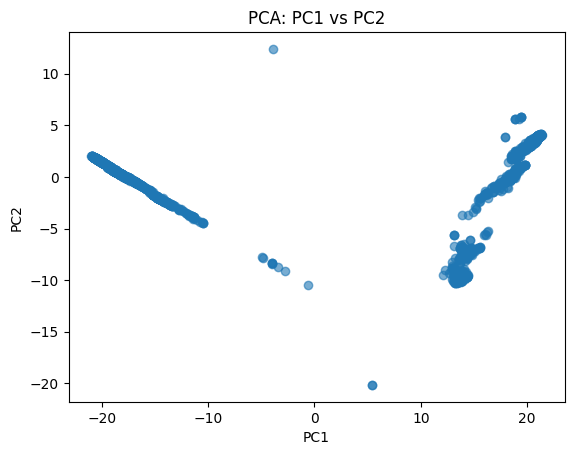

In [3]:
plt.scatter(principal_components_MSA[:, 0], principal_components_MSA[:, 1], alpha=0.6) #Generating Graphical Representation of PCA 1 and 2
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.show()


Now after completing the PCA we will use the reduced Data to identify clusters using k-means clustering.

In [13]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sequence_ids = df_distance_matrix.index.tolist()


# Use only PC1 (make it 2D to satisfy scikit-learn's input format)
pc1_only = principal_components_MSA[:, [0]]  # Shape: (n_samples, 1)

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(principal_components_MSA)
labels = kmeans.labels_

# Now create the DataFrame after labels are ready
df_clusters = pd.DataFrame(principal_components_MSA, columns=['PC1', 'PC2', 'PC3'], index=sequence_ids)
df_clusters['Cluster'] = labels

print(df_clusters.head())

df_clusters.to_csv('antibodies_pca_clusters.csv')



                                       PC1       PC2       PC3  Cluster
7ZOZ_2|H|antigen_species=homo   -17.774919 -0.038323 -2.257157        1
7ZOZ_3|L|antigen_species=homo    19.201329  2.426000 -0.645406        0
6PE8_1|A,H|antigen_species=homo -20.560191  1.775447  2.087733        1
6PE8_2|B,L|antigen_species=homo  19.858486  2.790911 -0.329514        0
8IVX_2|H|antigen_species=homo   -14.320396 -2.125524 -1.785295        1


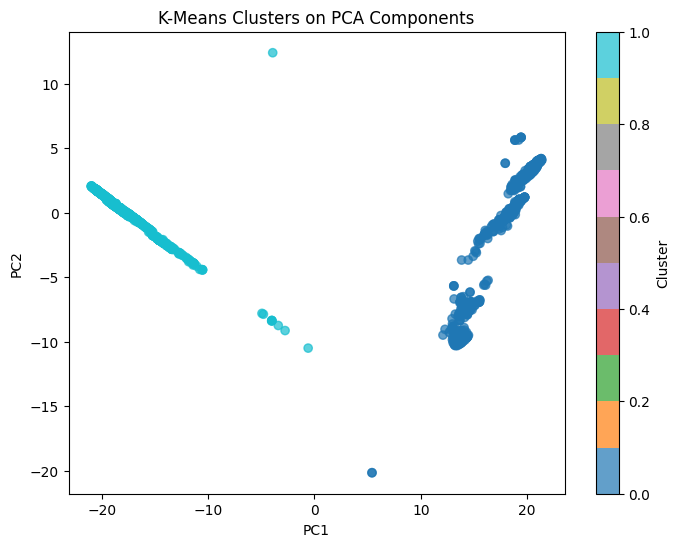

In [14]:
import matplotlib.pyplot as plt #Visualizing the Clusters

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_clusters['PC1'], df_clusters['PC2'], c=df_clusters['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Components')
plt.colorbar(scatter, label='Cluster')
plt.show()
